In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.6 MB/s eta 0:00:00


In [33]:
import cv2
import numpy as np
from ultralytics import YOLOE

model = YOLOE("yoloe-11l-seg.pt")
names = ["bracelet", "watch"]
model.set_classes(names, model.get_text_pe(names))

img_src = cv2.imread("src.jpg")
img_dst = cv2.imread("dst.png")

img_src_resized = cv2.resize(img_src, (img_dst.shape[1], img_dst.shape[0]))

results = model.predict(img_src_resized)[0]

temp = []

for i, mask in enumerate(results.masks.data):
    mask = mask.cpu().numpy()
    mask = cv2.resize(mask, (img_src_resized.shape[1], img_src_resized.shape[0]))
    mask = (mask > 0.5).astype(np.uint8) * 255

    x1, y1, x2, y2 = results.boxes.xyxy[i].cpu().numpy().astype(int)
    print(x1, y1, x2, y2)

    obj = cv2.bitwise_and(img_src_resized, img_src_resized, mask=mask)

    obj_crop = obj[y1:y2, x1:x2]
    mask_crop = mask[y1:y2, x1:x2]

    # break

    roi = img_dst[y1:y2, x1:x2,:]

    temp.append((obj_crop, mask_crop, roi))

    mask_crop_3ch = cv2.merge([mask_crop, mask_crop, mask_crop])
    mask_bin = (mask_crop_3ch > 0).astype(np.uint8)

    if roi.shape != obj_crop.shape:
        obj_crop = cv2.resize(obj_crop, (roi.shape[1], roi.shape[0]))
        mask_bin = cv2.resize(mask_bin, (roi.shape[1], roi.shape[0]))

    break
    roi = roi * (1 - mask_bin) + obj_crop * mask_bin
    img_dst[y1:y2, x1:x2] = roi

cv2.imwrite("result.jpg", img_dst)


0: 640x480 1 bracelet, 1 watch, 1922.1ms
Speed: 4.6ms preprocess, 1922.1ms inference, 4.8ms postprocess per image at shape (1, 3, 640, 480)
428 792 462 806


True

In [ ]:
obj_crop_3ch = cv2.merge([obj_crop, obj_crop, obj_crop])

In [21]:
obj.shape

(1024, 768, 3)

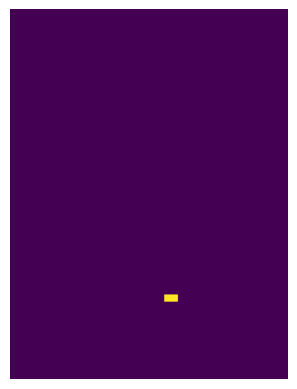

In [26]:
plt.imshow(mask)
plt.axis('off')
plt.savefig("bb.jpg")

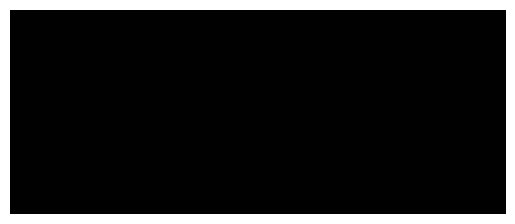

In [27]:
plt.imshow(mask_bin)
plt.axis('off')
plt.savefig("mask_bin.jpg")

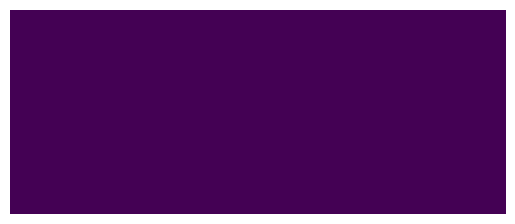

In [18]:
import matplotlib.pyplot as plt

plt.imshow(mask_crop)
plt.axis('off')
plt.savefig("mask_crop")

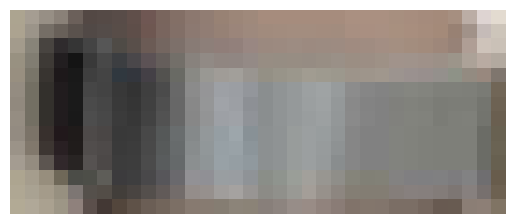

In [19]:
obj_crop = cv2.cvtColor(obj_crop, cv2.COLOR_BGR2RGB)
plt.imshow(obj_crop)
plt.axis('off')
plt.savefig("obj_crop")

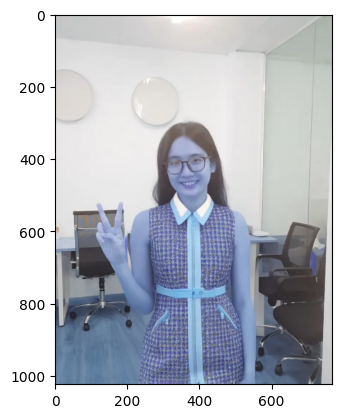

In [ ]:
plt.imshow(img_dst)

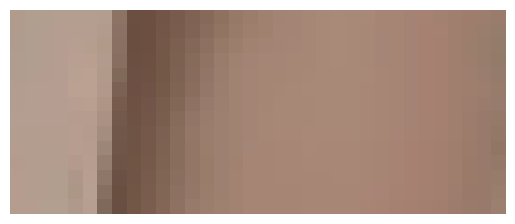

In [36]:
# roi = img_dst[932:956, 514:557]
roi = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
plt.axis('off')
plt.imshow(roi)
plt.savefig("roi.png")

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLOE
from google.colab.patches import cv2_imshow

# Load YOLOE segmentation model
model = YOLOE("yoloe-11l-seg.pt")

# Define target object classes (you can modify or generalize)
names = ["bracelet", "watch", "bag"]
model.set_classes(names, model.get_text_pe(names))

# Read the input (source) image
img_src = cv2.imread("1.jpg")

# Run segmentation
results = model.predict(img_src)[0]

# Iterate through each detected mask
for i, mask in enumerate(results.masks.data):
    # Convert tensor → NumPy array
    mask = mask.cpu().numpy()

    # Resize mask to match original image resolution
    mask = cv2.resize(mask, (img_src.shape[1], img_src.shape[0]))

    # Binarize mask: values > 0.5 become 255 (white), else 0 (black)
    binary_mask = (mask > 0.5).astype(np.uint8) * 255

    # Save binary mask
    cv2.imwrite(f"mask_{i}.png", binary_mask)

    # (Optional) visualize
    cv2_imshow(binary_mask)
    cv2.waitKey(0)

cv2.destroyAllWindows()

In [ ]:
obj_crop, mask_crop, roi = temp[0]

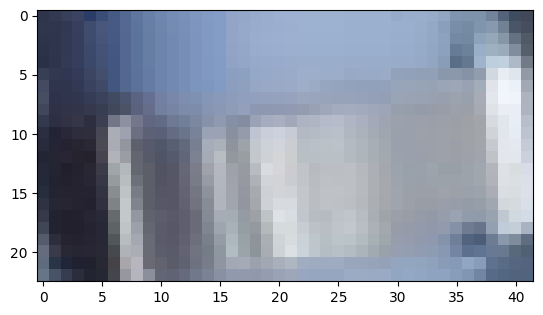

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(roi)

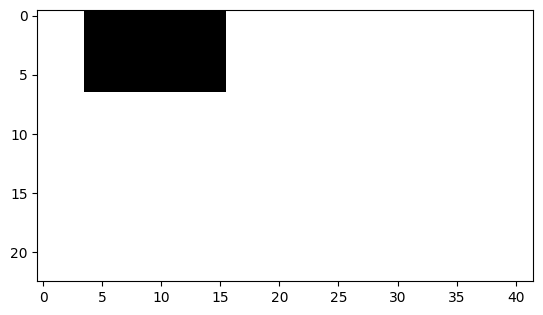

In [ ]:
plt.imshow(mask_crop_3ch)